In [1]:
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt

In [2]:
filename = '/dat/milic/SUSI_modeling/extended_off_limb_ssd_cube_paper_angle_80extended_off_limb_ssd_full_0.fits'

In [3]:
spectrum_ssd = fits.open(filename)[0].data

In [4]:
spectrum_ssd = fits.open(filename)[0].data

In [5]:
ll = fits.open(filename)[1].data
print(ll)

[392.8   392.802 392.804 ... 394.796 394.798 394.8  ]


In [6]:
filename_en = '/dat/milic/SUSI_modeling/extended_off_limb_cube_paper_angle_80full_0.fits'

In [7]:
spectrum_en = fits.open(filename_en)[0].data
spectrum_en = fits.open(filename_en)[0].data
ll_en = fits.open(filename_en)[1].data
print(ll_en)

[392.8   392.802 392.804 ... 394.796 394.798 394.8  ]


In [8]:
def vac_to_air(wavelength_vac):
    """Convert vacuum wavelength to air wavelength using the formula from Ciddor (1996)."""
    sigma2 = (1e4 / wavelength_vac)**2  # Convert from nm to microns^-2
    n = 1 + 0.0000834254 + (0.02406147 / (130 - sigma2)) + (0.00015998 / (38.9 - sigma2))
    wavelength_air = wavelength_vac / n
    return wavelength_air   


In [9]:
ll_air_ssd = vac_to_air(ll)
ll_air_en = vac_to_air(ll_en)

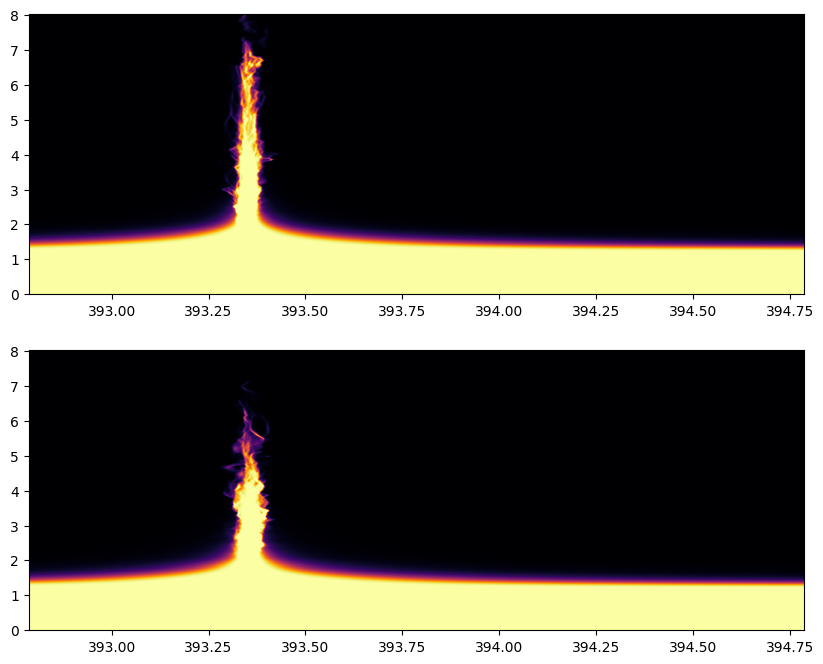

In [11]:
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.imshow(spectrum_ssd[0,:,:],cmap='inferno',origin='lower', extent=[ll_air_ssd[0], ll_air_ssd[-1], 0, spectrum_ssd.shape[1]*0.02], aspect='auto')
plt.subplot(212)
plt.imshow(spectrum_en[0,:,:],cmap='inferno',origin='lower', extent=[ll_air_en[0], ll_air_en[-1], 0, spectrum_en.shape[1]*0.02], aspect='auto')

In [12]:
# Convert wavelengths in velocities.
# First find the maximum:
I_mean_ssd = np.mean(spectrum_ssd, axis=(1,2))
max_index_ssd = np.argmax(I_mean_ssd)
print(max_index_ssd)

293


In [13]:
# Convert wavelengths in velocities.
# First find the maximum:
I_mean_en = np.mean(spectrum_en, axis=(1,2))
max_index_en = np.argmax(I_mean_en)
print(max_index_en)

276


In [15]:
# Let's real quick convolve spatially our data with the Sunrise PSF
from astropy.convolution import AiryDisk2DKernel
# What is the first zero of our PSF? 
diff_limit = 1.22 * 392.8E-9 / 1.0 * 206265.0 * 725 #
diff_limit_pixels = diff_limit / 22.0
print(diff_limit_pixels)
Sunrise_PSF = AiryDisk2DKernel(diff_limit_pixels, x_size=33, y_size=33)
#plt.imshow(np.log10(Sunrise_PSF.array), cmap='inferno', origin='lower')
#plt.colorbar()

3.257408135181818


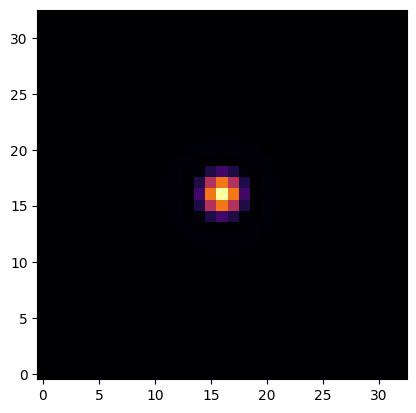

In [16]:
plt.imshow(Sunrise_PSF.array, cmap='inferno', origin='lower')   

In [17]:
# Convolve the spectrum in space quickly:

from astropy.convolution import convolve_fft, convolve
from tqdm import tqdm

NX, NZ, NL = spectrum_ssd.shape

spectrum_ssd_convolved = np.zeros_like(spectrum_ssd)
spectrum_en_convolved = np.zeros_like(spectrum_en)

for i in tqdm(range(NL)):
    
    spectrum_ssd_convolved[:,:,i] = convolve(spectrum_ssd[:,:,i], Sunrise_PSF, boundary='extend', normalize_kernel=True)
    spectrum_en_convolved[:,:,i] = convolve(spectrum_en[:,:,i], Sunrise_PSF, boundary='extend', normalize_kernel=True)

100%|██████████| 1001/1001 [13:26<00:00,  1.24it/s]


In [18]:
# Now create filtergraph by integrating over the wavelength axis, but only the points 0.1 nm around the core of the line:
filtergraph_ssd = np.sum(spectrum_ssd_convolved[:, :, (ll_air_ssd - ll_air_ssd[max_index_ssd] > -0.05) & (ll_air_ssd - ll_air_ssd[max_index_ssd] < 0.05)], axis=2)
filtergraph_en = np.sum(spectrum_en_convolved[:, :, (ll_air_en - ll_air_en[max_index_en] > -0.05) & (ll_air_en - ll_air_en[max_index_en] < 0.05)], axis=2)   
print(filtergraph_ssd.shape)
print(filtergraph_en.shape)

(1024, 401)
(1024, 401)


In [19]:
x = np.arange(spectrum_ssd.shape[0]) * 0.024 * np.sin(np.radians(80))
z = (np.arange(spectrum_ssd.shape[1])-68) * 0.02 

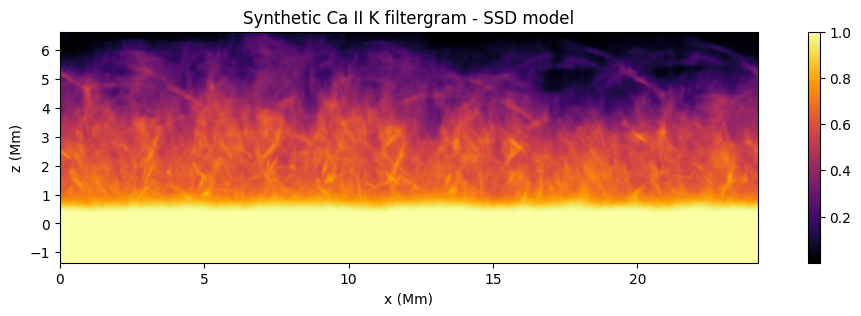

In [21]:
# Now create a plot:

plt.figure(figsize=(13,3))
plt.imshow(filtergraph_ssd.T/np.amax(filtergraph_ssd), origin='lower', cmap='inferno', extent=[x[0], x[-1], z[0], z[-1]], rasterized=True)
plt.title('Synthetic Ca II K filtergram - SSD model')
plt.xlabel('x (Mm)')
plt.ylabel('Height (Mm)')
plt.colorbar()
plt.savefig('figs/filtergram_c_ssd.png', dpi=300,bbox_inches='tight')
plt.savefig('figs/filtergram_c_ssd.pdf', dpi=300,bbox_inches='tight')
# Looks good

In [26]:
# Change the font size real quick
plt.rcParams.update({'font.size': 15})

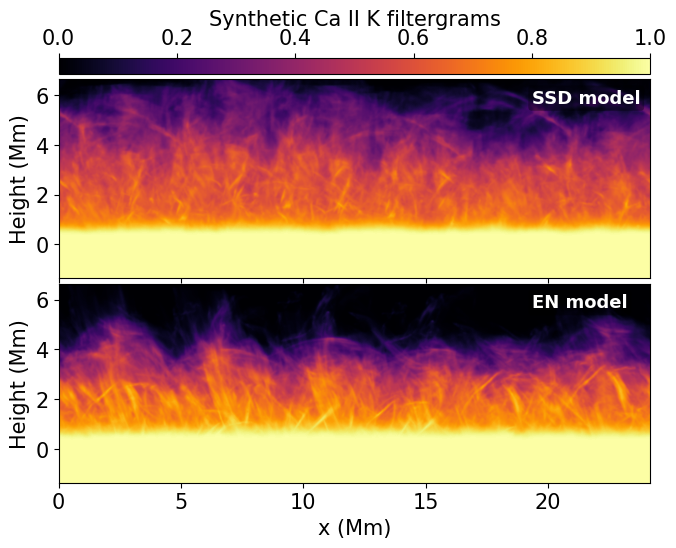

In [30]:
# Stacked filtergrams with a shared colorbar on top (compact half-page style)

ssd_norm = filtergraph_ssd.T / np.nanmax(filtergraph_ssd)
en_norm = filtergraph_en.T / np.nanmax(filtergraph_en)

fig = plt.figure(figsize=(6.8, 5.0))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[0.08, 1, 1], hspace=0.04)

ax_cbar = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0], sharex=ax1, sharey=ax1)

extent = [x[0], x[-1], z[0], z[-1]]
im1 = ax1.imshow(ssd_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1, rasterized=True)
im2 = ax2.imshow(en_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1, rasterized=True)

ax1.text(0.8, 0.95, "SSD model", transform=ax1.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))
ax2.text(0.8, 0.95, "EN model", transform=ax2.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))

ax1.set_ylabel("Height (Mm)")
ax2.set_ylabel("Height (Mm)")
ax2.set_xlabel("x (Mm)")
ax1.tick_params(labelbottom=False)

cbar = fig.colorbar(im1, cax=ax_cbar, orientation='horizontal')
cbar.set_label("Synthetic Ca II K filtergrams", labelpad=2)
ax_cbar.xaxis.set_ticks_position('top')
ax_cbar.xaxis.set_label_position('top')

fig.subplots_adjust(left=0.11, right=0.98, bottom=0.10, top=0.95)
plt.savefig("figs/filtergrams_stacked_joint_cbar.png", dpi=300, bbox_inches='tight')
plt.savefig("figs/filtergrams_stacked_joint_cbar.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
I_clv = np.sum(spectrum_ssd_convolved, axis=(0,2))

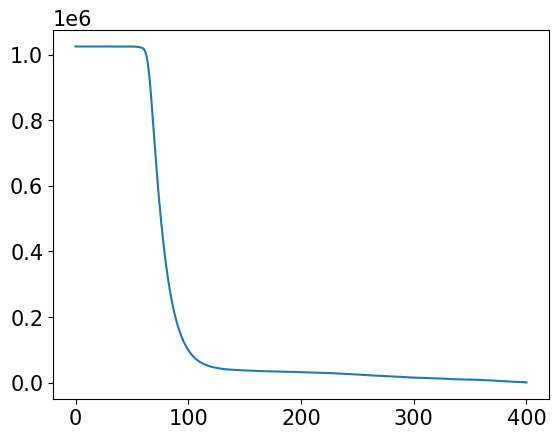

In [34]:
plt.plot(I_clv)

(60.0, 75.0)

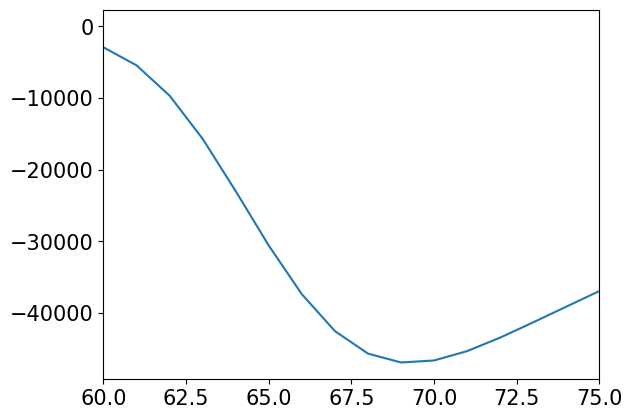

In [35]:
plt.plot(np.gradient(I_clv))
plt.xlim([60,75])

In [36]:
# Limb is @ 69

In [37]:
# Load normalized off-limb spectrum from file
path = '/dat/milic/SUSI_modeling/susi_cube_202407132153_normalized.fits'
cube = fits.open(path)[0].data
ll_obs = fits.open(path)[1].data
limbdistances_obs = fits.open(path)[2].data
velocities_obs = fits.open(path)[3].data

In [38]:
cube.shape

(240, 1556, 1912)

In [39]:
# find where plus minus 50 km/s are in the observed spectrum:
index_vel_minus_50 = np.argmin(np.abs(velocities_obs + 50))
index_vel_plus_50 = np.argmin(np.abs(velocities_obs - 50))
print(f"Index for -50 km/s: {index_vel_minus_50}, wavelength: {ll_obs[index_vel_minus_50]:.3f} nm")
print(f"Index for +50 km/s: {index_vel_plus_50}, wavelength: {ll_obs[index_vel_plus_50]:.3f} nm")

Index for -50 km/s: 475, wavelength: 393.301 nm
Index for +50 km/s: 603, wavelength: 393.432 nm


In [40]:
# and the same in the synthetic air spectrum:
# define the line center as the wavelength corresponding to the line core in the observations:
central_wavelength_obs = ll_obs[np.argmin(np.abs(velocities_obs))]

index_vel_minus_50_synth_ssd = np.argmin(np.abs(ll_air_ssd - (central_wavelength_obs * (1 - 50/3E5))))
index_vel_plus_50_synth_ssd = np.argmin(np.abs(ll_air_ssd - (central_wavelength_obs * (1 + 50/3E5))))
print(f"Synthetic -50 km/s: index {index_vel_minus_50_synth_ssd}, wavelength: {ll_air_ssd[index_vel_minus_50_synth_ssd]:.3f} nm")
print(f"Synthetic +50 km/s: index {index_vel_plus_50_synth_ssd}, wavelength: {ll_air_ssd[index_vel_plus_50_synth_ssd]:.3f} nm")

Synthetic -50 km/s: index 258, wavelength: 393.302 nm
Synthetic +50 km/s: index 323, wavelength: 393.432 nm


In [41]:
# and the same in the synthetic air spectrum:
# define the line center as the wavelength corresponding to the line core in the observations:
central_wavelength_obs = ll_obs[np.argmin(np.abs(velocities_obs))]

index_vel_minus_50_synth_en = np.argmin(np.abs(ll_air_en - (central_wavelength_obs * (1 - 50/3E5))))
index_vel_plus_50_synth_en = np.argmin(np.abs(ll_air_en - (central_wavelength_obs * (1 + 50/3E5))))
print(f"Synthetic -50 km/s: index {index_vel_minus_50_synth_en}, wavelength: {ll_air_en[index_vel_minus_50_synth_en]:.3f} nm")
print(f"Synthetic +50 km/s: index {index_vel_plus_50_synth_en}, wavelength: {ll_air_en[index_vel_plus_50_synth_en]:.3f} nm")

Synthetic -50 km/s: index 258, wavelength: 393.302 nm
Synthetic +50 km/s: index 323, wavelength: 393.432 nm


In [42]:
# Adjust font size
plt.rcParams.update({'font.size': 14})

In [46]:
# We will convolve both the synthetic spectra with a Gaussian kernel to simulate the spectral resolution of the observations. Let's assume a spectral resolution of R = 100,000, which corresponds to a FWHM of about 0.004 nm at 393.4 nm.

fwhm = 0.004  # nm
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
sigma_pixels = sigma / (ll_air_ssd[1] - ll_air_ssd[0])  # Convert FWHM to pixels

from scipy.ndimage import gaussian_filter1d

spectrum_ssd_sconvolved = np.zeros_like(spectrum_ssd_convolved)
spectrum_en_sconvolved = np.zeros_like(spectrum_en_convolved)

for tqdm_index in tqdm(range(spectrum_ssd_convolved.shape[0])):
    for z_index in range(spectrum_ssd_convolved.shape[1]):
        spectrum_ssd_sconvolved[tqdm_index, z_index, :] = gaussian_filter1d(spectrum_ssd_convolved[tqdm_index, z_index, :], sigma=sigma_pixels)
        spectrum_en_sconvolved[tqdm_index, z_index, :] = gaussian_filter1d(spectrum_en_convolved[tqdm_index, z_index, :], sigma=sigma_pixels)





100%|██████████| 1024/1024 [00:22<00:00, 46.01it/s]


In [48]:
# Save the convolved spectra to FITS files
output_filename_ssd = '/dat/milic/SUSI_modeling/spectrum_ssd_convolved.fits'
output_filename_en = '/dat/milic/SUSI_modeling/spectrum_en_convolved.fits'

hdu_ssd = fits.PrimaryHDU(spectrum_ssd_sconvolved)
hdu_ssd_ll = fits.ImageHDU(ll_air_ssd)
hdu_ssd_list = fits.HDUList([hdu_ssd, hdu_ssd_ll])
hdu_ssd_list.writeto(output_filename_ssd, overwrite=True)

hdu_en = fits.PrimaryHDU(spectrum_en_sconvolved)
hdu_en_ll = fits.ImageHDU(ll_air_en)
hdu_en_list = fits.HDUList([hdu_en, hdu_en_ll])
hdu_en_list.writeto(output_filename_en, overwrite=True)


In [50]:
# Now find the x coordintes where x = 8 Mm for ssd and 6.5 Mm for en, and plot the spectra at those x coordinates.
x_coord_ssd = 8.0  # Mm
x_coord_en = 6.5  # Mm

# Indices:
index_ssd = np.argmin(np.abs(x - x_coord_ssd))
index_en = np.argmin(np.abs(x - x_coord_en))


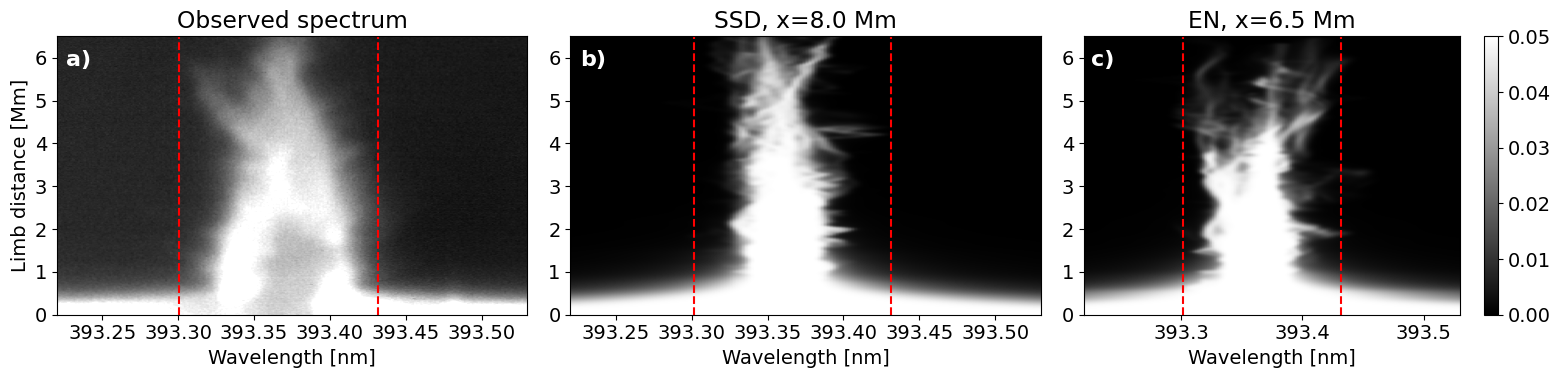

In [52]:
# Show a comparison between the first time instance of the observed spectrum and some example synthetic spectra, without 
# any spatial averaging.

plt.figure(figsize=(16,4))
plt.subplot(131)
plt.imshow(cube[1], origin='lower', extent=[ll_obs[0],ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.xlim(393.22, 393.53)
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("Observed spectrum")
# denote panel with a)
plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(132)
plt.imshow(spectrum_ssd_sconvolved[index_ssd]*0.05, origin='lower', extent=[ll_air_ssd[0]+0.01,ll_air_ssd[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll_air_ssd[index_vel_minus_50_synth_ssd], ll_air_ssd[index_vel_plus_50_synth_ssd]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.title(f"SSD, x={x_coord_ssd} Mm")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(133)
plt.imshow(spectrum_en_sconvolved[index_en]*0.05, origin='lower', extent=[ll_air_en[0]+0.01,ll_air_en[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll_air_en[index_vel_minus_50_synth_en], ll_air_en[index_vel_plus_50_synth_en]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.title(f"EN, x={x_coord_en} Mm")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'c)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.tight_layout()
plt.savefig("figs/off_limb_slit_detailed_examples.png",bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_detailed_examples.pdf",bbox_inches='tight', dpi=300)

In [ ]:
# re-do the plot above by using subplots for three spectra and then a separate axis for the colorbar so that all three spectra have the same extent and colorbar.
# and also make it so they share the y axis



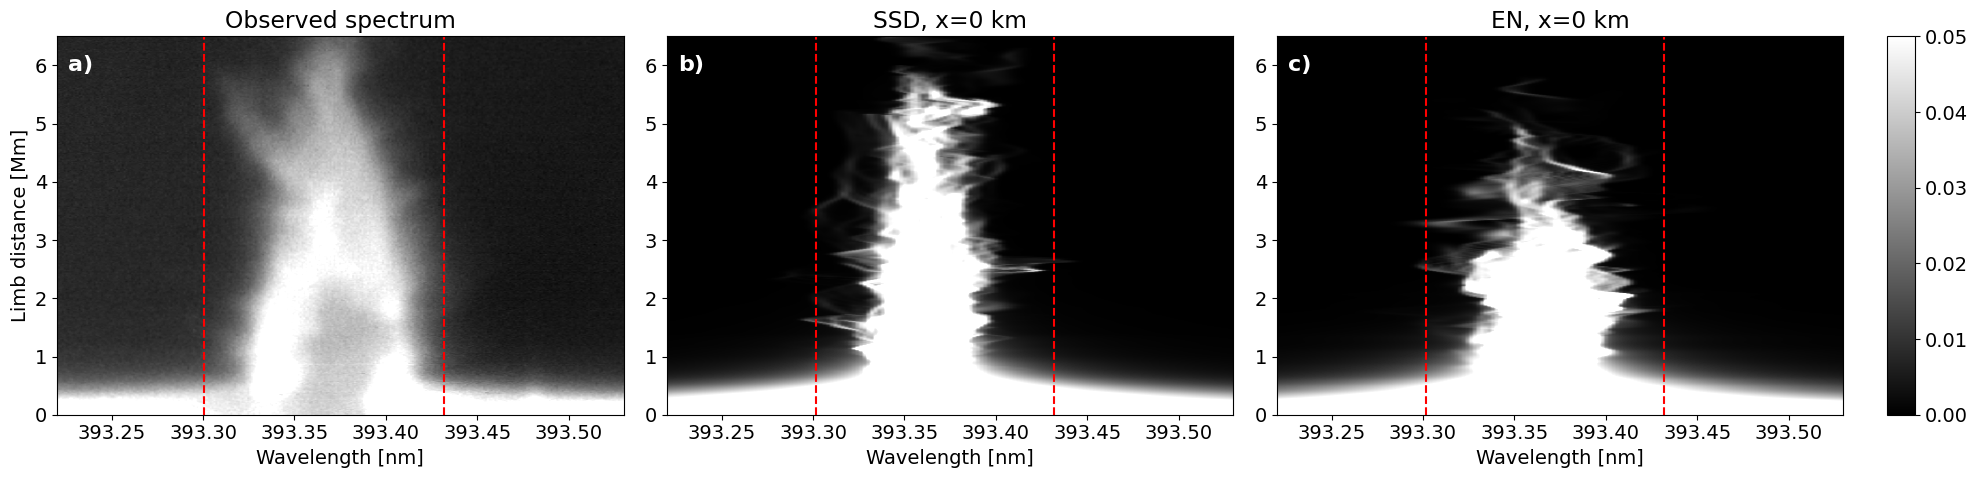

In [40]:
from matplotlib.gridspec import GridSpec

# re-do the plot above by using subplots for three spectra and then a separate axis for the colorbar so that all three spectra have the same extent and colorbar.
fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.05])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
ax_cbar = fig.add_subplot(gs[0, 3])

im1 = ax1.imshow(cube[1], origin='lower', extent=[ll_obs[0], ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
ax1.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
ax1.set_xlim(393.22, 393.53)
ax1.set_ylim(0, 6.5)
ax1.set_ylabel("Limb distance [Mm]")
ax1.set_xlabel("Wavelength [nm]")
ax1.set_title("Observed spectrum")
ax1.text(0.02, 0.95, 'a)', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

im2 = ax2.imshow(spectrum_ssd[0]*0.06, origin='lower', extent=[ll_air_ssd[0]+0.01, ll_air_ssd[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray',rasterized=True)
ax2.vlines([ll_air_ssd[index_vel_minus_50_synth], ll_air_ssd[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
ax2.set_xlim(393.22, 393.53)
ax2.set_xlabel("Wavelength [nm]")
ax2.set_title("SSD, x=0 km")
ax2.text(0.02, 0.95, 'b)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

im3 = ax3.imshow(spectrum_en[0]*0.06, origin='lower', extent=[ll_air_en[0]+0.01, ll_air_en[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
ax3.vlines([ll_air_en[index_vel_minus_50_synth], ll_air_en[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
ax3.set_xlim(393.22, 393.53)
ax3.set_xlabel("Wavelength [nm]")
ax3.set_title("EN, x=0 km")
ax3.text(0.02, 0.95, 'c)', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.colorbar(im3, cax=ax_cbar)
plt.tight_layout()
plt.savefig("figs/off_limb_slit_detailed.png", bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_detailed.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Average synthetic spectrum over the first axis: 

cube_int = np.mean(cube[:-1], axis=0)

In [46]:
spec_int_ssd = np.mean(spectrum_ssd[:128], axis=0)
spec_int_en = np.mean(spectrum_en[:128], axis=0)


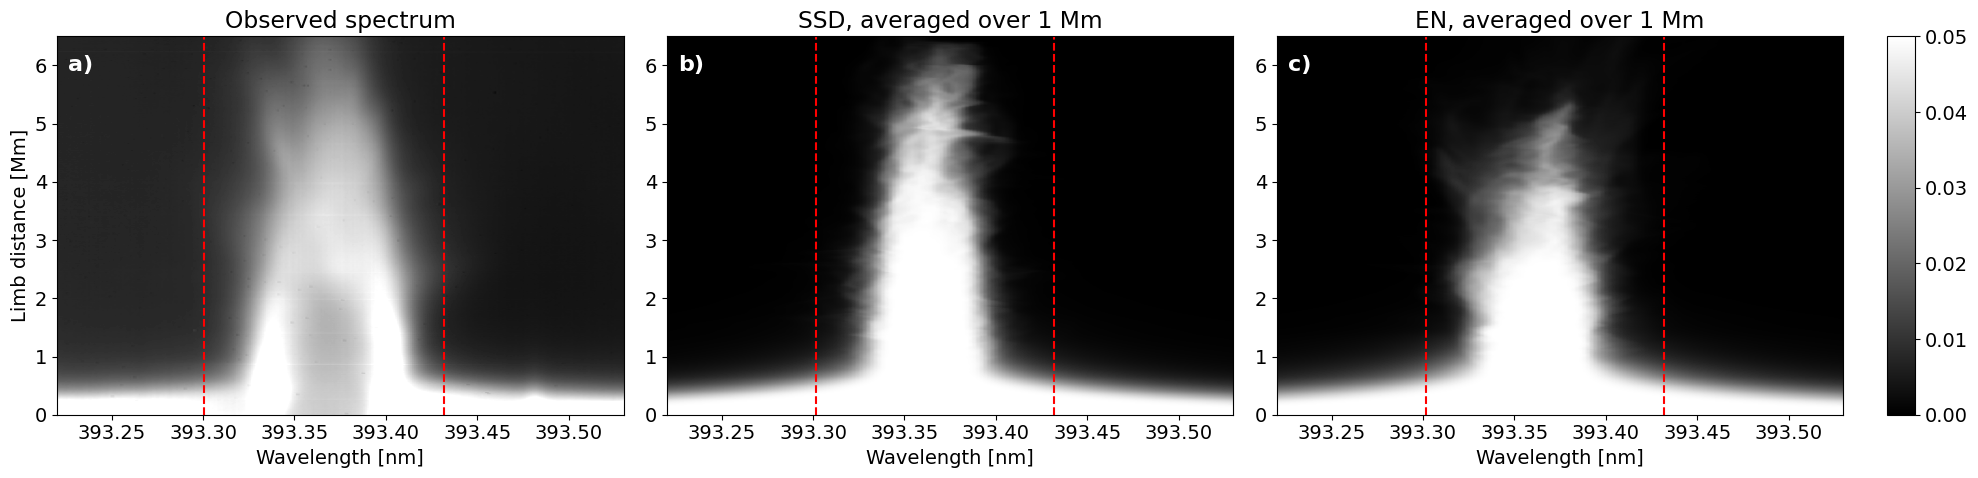

In [ ]:
from matplotlib.gridspec import GridSpec

# re-do the plot above by using subplots for three spectra and then a separate axis for the colorbar so that all three spectra have the same extent and colorbar.
fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.05])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
ax_cbar = fig.add_subplot(gs[0, 3])

im1 = ax1.imshow(cube_int, origin='lower', extent=[ll_obs[0], ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
ax1.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
ax1.set_xlim(393.22, 393.53)
ax1.set_ylim(0, 6.5)
ax1.set_ylabel("Limb distance [Mm]")
ax1.set_xlabel("Wavelength [nm]")
ax1.set_title("Time-averaged observed spectrum")
ax1.text(0.02, 0.95, 'a)', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

im2 = ax2.imshow(spec_int_ssd*0.05, origin='lower', extent=[ll_air_ssd[0]+0.01, ll_air_ssd[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray',rasterized=True)
ax2.vlines([ll_air_ssd[index_vel_minus_50_synth], ll_air_ssd[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
ax2.set_xlim(393.22, 393.53)
ax2.set_xlabel("Wavelength [nm]")
ax2.set_title("SSD, averaged over 2 Mm")
ax2.text(0.02, 0.95, 'b)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

im3 = ax3.imshow(spec_int_en*0.05, origin='lower', extent=[ll_air_en[0]+0.01, ll_air_en[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
ax3.vlines([ll_air_en[index_vel_minus_50_synth], ll_air_en[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
ax3.set_xlim(393.22, 393.53)
ax3.set_xlabel("Wavelength [nm]")
ax3.set_title("EN, averaged over 2 Mm")
ax3.text(0.02, 0.95, 'c)', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.colorbar(im3, cax=ax_cbar)
plt.tight_layout()
plt.savefig("figs/off_limb_slit_averaged.png", bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_averaged.pdf", bbox_inches='tight', dpi=300)
plt.show()